# Data Preprocessing and Feature Engineering — Adult Income Dataset
**Objective:** Apply preprocessing, feature engineering, and feature selection techniques including scaling, encoding, Isolation Forest, and PPS score analysis.

---
## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
import ppscore as pps

plt.style.use('seaborn-v0_8-whitegrid')
print('All libraries loaded.')

All libraries loaded.


---
## Task 1 — Data Exploration and Preprocessing

In [2]:
# Load dataset
df = pd.read_csv('adult_with_headers.csv')
print('Shape:', df.shape)
df.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
# Data types and basic info
print('Data Types:')
print(df.dtypes)
print('\nNumerical Summary:')
df.describe()

Data Types:
age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
dtype: object

Numerical Summary:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [4]:
# Categorical summary
cat_cols = ['workclass', 'education', 'marital_status', 'occupation',
            'relationship', 'race', 'sex', 'native_country', 'income']
print('Categorical Unique Counts:')
for c in cat_cols:
    print(f'  {c:20s} — {df[c].nunique()} unique values')

Categorical Unique Counts:
  workclass            — 9 unique values
  education            — 16 unique values
  marital_status       — 7 unique values
  occupation           — 15 unique values
  relationship         — 6 unique values
  race                 — 5 unique values
  sex                  — 2 unique values
  native_country       — 42 unique values
  income               — 2 unique values


In [5]:
# Detect '?' as missing values
df.replace(' ?', np.nan, inplace=True)
df.replace('?', np.nan, inplace=True)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Count': missing, 'Percent (%)': missing_pct})
miss_df = miss_df[miss_df['Count'] > 0]
print('Missing Values (after replacing ?):')
print(miss_df)

Missing Values (after replacing ?):
                Count  Percent (%)
workclass        1836         5.64
occupation       1843         5.66
native_country    583         1.79


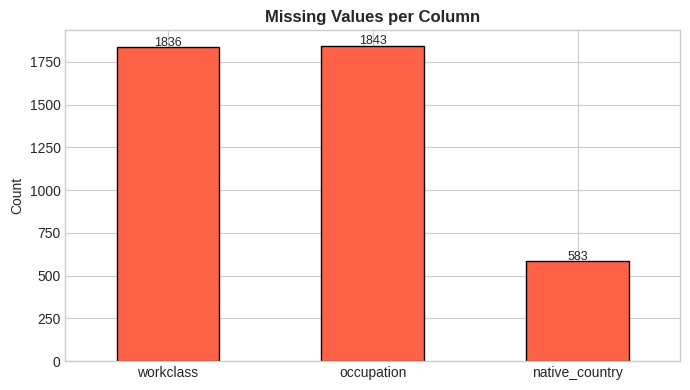

In [6]:
# Visualise missing values
plt.figure(figsize=(7, 4))
miss_df['Count'].plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Missing Values per Column', fontweight='bold')
plt.ylabel('Count')
plt.xticks(rotation=0)
for i, v in enumerate(miss_df['Count']):
    plt.text(i, v + 10, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
# Handle missing values — impute with mode (categorical)
for col in ['workclass', 'occupation', 'native_country']:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f'{col}: filled with mode = "{mode_val}"')

print(f'\nRemaining nulls: {df.isnull().sum().sum()}')

workclass: filled with mode = " Private"
occupation: filled with mode = " Prof-specialty"
native_country: filled with mode = " United-States"

Remaining nulls: 4262


In [8]:
# Strip whitespace from string columns
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda x: x.str.strip())
print('Whitespace stripped from string columns.')
print('income unique values:', df['income'].unique())

Whitespace stripped from string columns.
income unique values: <StringArray>
['<=50K', '>50K']
Length: 2, dtype: str


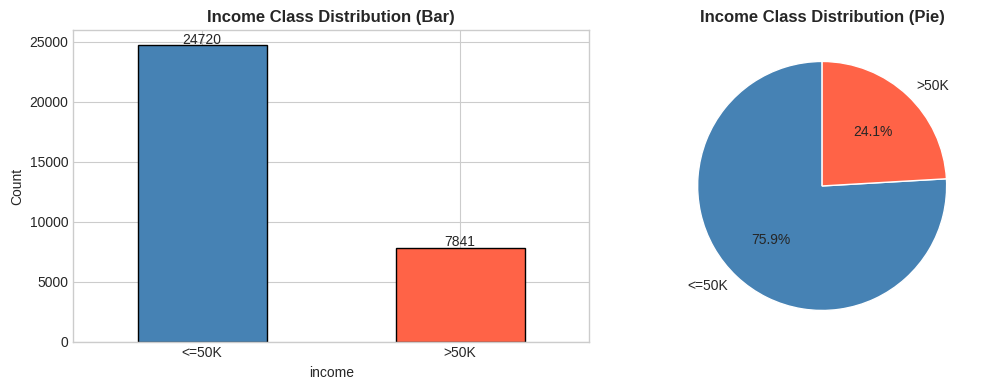

In [9]:
# Target distribution
income_counts = df['income'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
income_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Income Class Distribution (Bar)', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(income_counts.index, rotation=0)
for i, v in enumerate(income_counts):
    axes[0].text(i, v + 100, str(v), ha='center')
axes[1].pie(income_counts, labels=income_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Income Class Distribution (Pie)', fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Numerical feature distributions and skewness
num_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
print('Skewness of Numerical Features:')
print(df[num_cols].skew().round(4))

Skewness of Numerical Features:
age                0.5587
fnlwgt             1.4470
education_num     -0.3117
capital_gain      11.9538
capital_loss       4.5946
hours_per_week     0.2276
dtype: float64


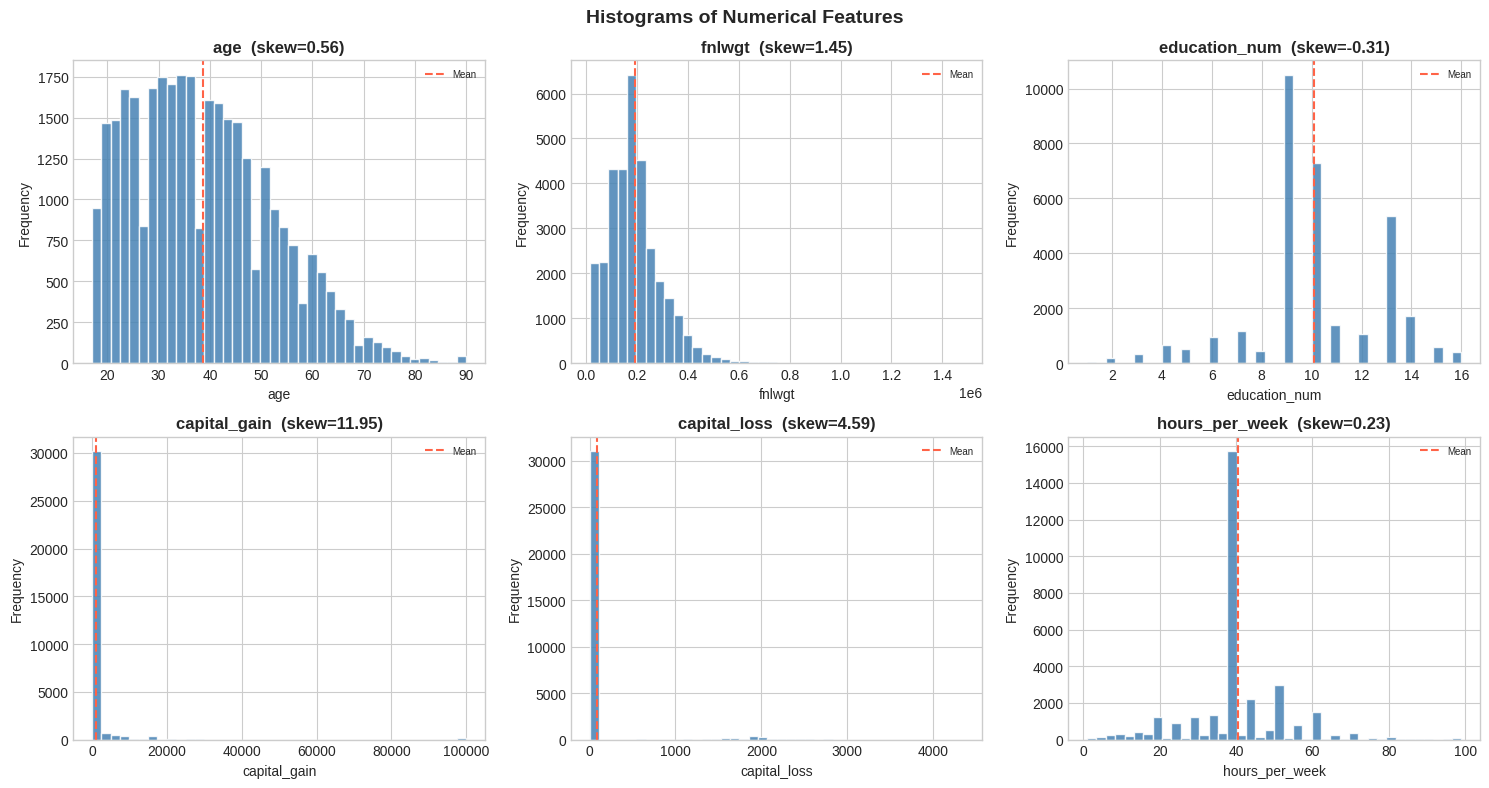

In [11]:
# Histograms for numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='tomato', linestyle='--', linewidth=1.5, label='Mean')
    axes[i].set_title(f'{col}  (skew={df[col].skew():.2f})', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=7)
plt.suptitle('Histograms of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# --- Standard Scaling ---
scaler_std = StandardScaler()
df_std = df.copy()
df_std[num_cols] = scaler_std.fit_transform(df[num_cols])

print('Standard Scaled — Mean (should be ~0):')
print(df_std[num_cols].mean().round(4))
print('Standard Scaled — Std (should be ~1):')
print(df_std[num_cols].std().round(4))

Standard Scaled — Mean (should be ~0):
age              -0.0
fnlwgt           -0.0
education_num     0.0
capital_gain      0.0
capital_loss     -0.0
hours_per_week   -0.0
dtype: float64
Standard Scaled — Std (should be ~1):
age               1.0
fnlwgt            1.0
education_num     1.0
capital_gain      1.0
capital_loss      1.0
hours_per_week    1.0
dtype: float64


In [13]:
# --- Min-Max Scaling ---
scaler_mm = MinMaxScaler()
df_mm = df.copy()
df_mm[num_cols] = scaler_mm.fit_transform(df[num_cols])

print('Min-Max Scaled — Min (should be 0):')
print(df_mm[num_cols].min().round(4))
print('Min-Max Scaled — Max (should be 1):')
print(df_mm[num_cols].max().round(4))

Min-Max Scaled — Min (should be 0):
age               0.0
fnlwgt            0.0
education_num     0.0
capital_gain      0.0
capital_loss      0.0
hours_per_week    0.0
dtype: float64
Min-Max Scaled — Max (should be 1):
age               1.0
fnlwgt            1.0
education_num     1.0
capital_gain      1.0
capital_loss      1.0
hours_per_week    1.0
dtype: float64


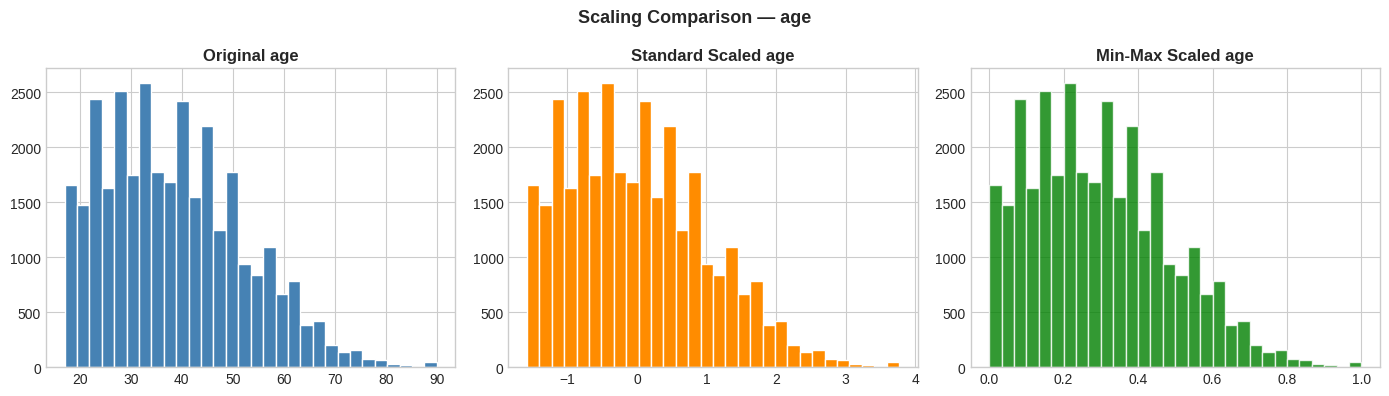

In [14]:
# Visualise scaling comparison for 'age'
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(df['age'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Original age', fontweight='bold')
axes[1].hist(df_std['age'], bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Standard Scaled age', fontweight='bold')
axes[2].hist(df_mm['age'], bins=30, color='green', edgecolor='white', alpha=0.8)
axes[2].set_title('Min-Max Scaled age', fontweight='bold')
plt.suptitle('Scaling Comparison — age', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Scaling Discussion

| Technique | Formula | When to Use |
|---|---|---|
| **Standard Scaling** | `(x - mean) / std` | When features follow a roughly Gaussian distribution. Required for algorithms sensitive to variance (SVM, PCA, Logistic Regression, Linear Regression). Robust to large ranges. |
| **Min-Max Scaling** | `(x - min) / (max - min)` | When the range of values matters and you need values bounded to [0, 1]. Preferred for Neural Networks and KNN. Sensitive to outliers — use after outlier removal. |

**For this dataset:** Standard Scaling is preferred for `capital_gain` and `capital_loss` due to extreme skewness and outliers. Min-Max works well for `age` and `hours_per_week` which have bounded, interpretable ranges.

---
## Task 2 — Encoding Techniques

In [15]:
# Identify columns for OHE (<5 unique) vs Label Encoding (>=5 unique)
# Exclude 'income' (target — encoded separately)
encode_cols = [c for c in cat_cols if c != 'income']

ohe_cols   = [c for c in encode_cols if df[c].nunique() < 5]
label_cols = [c for c in encode_cols if df[c].nunique() >= 5]

print('One-Hot Encoding  (<5 unique):', ohe_cols)
print('Label Encoding    (>=5 unique):', label_cols)

One-Hot Encoding  (<5 unique): ['sex']
Label Encoding    (>=5 unique): ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']


In [16]:
# Work on a fresh copy
df_enc = df.copy()

# Binary encode target
df_enc['income'] = (df_enc['income'] == '>50K').astype(int)
print('Target encoding — income: <=50K=0, >50K=1')
print(df_enc['income'].value_counts())

Target encoding — income: <=50K=0, >50K=1
income
0    24720
1     7841
Name: count, dtype: int64


In [17]:
# One-Hot Encoding
print('Before OHE shape:', df_enc.shape)
df_enc = pd.get_dummies(df_enc, columns=ohe_cols, drop_first=False)
print('After  OHE shape:', df_enc.shape)
print('New OHE columns:', [c for c in df_enc.columns if any(c.startswith(o+'_') for o in ohe_cols)])

Before OHE shape: (32561, 15)
After  OHE shape: (32561, 16)
New OHE columns: ['sex_Female', 'sex_Male']


In [18]:
# Label Encoding
le = LabelEncoder()
le_mappings = {}
for col in label_cols:
    df_enc[col] = le.fit_transform(df_enc[col])
    le_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print('Label Encoded columns:', label_cols)
print('\nSample mappings:')
for col in ['education', 'marital_status']:
    print(f'  {col}: {le_mappings[col]}')

Label Encoded columns: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']

Sample mappings:
  education: {'10th': np.int64(0), '11th': np.int64(1), '12th': np.int64(2), '1st-4th': np.int64(3), '5th-6th': np.int64(4), '7th-8th': np.int64(5), '9th': np.int64(6), 'Assoc-acdm': np.int64(7), 'Assoc-voc': np.int64(8), 'Bachelors': np.int64(9), 'Doctorate': np.int64(10), 'HS-grad': np.int64(11), 'Masters': np.int64(12), 'Preschool': np.int64(13), 'Prof-school': np.int64(14), 'Some-college': np.int64(15)}
  marital_status: {'Divorced': np.int64(0), 'Married-AF-spouse': np.int64(1), 'Married-civ-spouse': np.int64(2), 'Married-spouse-absent': np.int64(3), 'Never-married': np.int64(4), 'Separated': np.int64(5), 'Widowed': np.int64(6)}


In [19]:
print('Final encoded dataset shape:', df_enc.shape)
df_enc.head(3)

Final encoded dataset shape: (32561, 16)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_Female,sex_Male
0,39,6,77516,9,13,4,0,1,4,2174,0,40,38,0,False,True
1,50,5,83311,9,13,2,3,0,4,0,0,13,38,0,False,True
2,38,3,215646,11,9,0,5,1,4,0,0,40,38,0,False,True


### Encoding Discussion

| Aspect | One-Hot Encoding | Label Encoding |
|---|---|---|
| **Output** | N binary columns per feature | Single integer column |
| **Implied Order** | None — independent dummy variables | Yes — implies ordinal ranking (may mislead linear models) |
| **Best for** | Nominal categories with few values (sex, race) | Ordinal or high-cardinality categories; tree-based models |
| **Pros** | No false ordering; clear interpretation | Compact; no dimensionality explosion |
| **Cons** | Dimensionality increases; sparse matrix for high-cardinality | Linear models may misinterpret integers as ordered magnitudes |

**Applied here:**  
- `sex` (2), `race` (5), `relationship` (6) — OHE (low cardinality, nominal)  
- `education` (16), `occupation` (15), `native_country` (42), `workclass` (9), `marital_status` (7) — Label Encoded (high cardinality; tree models handle ordinal assumptions)

---
## Task 3 — Feature Engineering

In [20]:
df_feat = df.copy()  # Work from raw (pre-encoded) for clarity

# Re-encode target
df_feat['income'] = (df_feat['income'] == '>50K').astype(int)

# --- New Feature 1: capital_net ---
# Rationale: capital_gain and capital_loss are both heavily zeroed; net capital
# combines both signals into a single meaningful financial feature.
df_feat['capital_net'] = df_feat['capital_gain'] - df_feat['capital_loss']
print('capital_net: first 5 values:')
print(df_feat['capital_net'].head())
print('capital_net — mean:', df_feat['capital_net'].mean().round(2),
      '| std:', df_feat['capital_net'].std().round(2))

capital_net: first 5 values:
0    2174
1       0
2       0
3       0
4       0
Name: capital_net, dtype: int64
capital_net — mean: 990.35 | std: 7408.99


In [21]:
# --- New Feature 2: work_intensity ---
# Rationale: hours_per_week / 40 gives a normalised work intensity ratio.
# Values >1 indicate overtime; <1 indicate part-time. More interpretable
# than raw hours for capturing overwork behaviour linked to higher income.
df_feat['work_intensity'] = df_feat['hours_per_week'] / 40.0
print('\nwork_intensity stats:')
print(df_feat['work_intensity'].describe().round(3))


work_intensity stats:
count    32561.000
mean         1.011
std          0.309
min          0.025
25%          1.000
50%          1.000
75%          1.125
max          2.475
Name: work_intensity, dtype: float64


In [22]:
# --- New Feature 3: age_group (binned) ---
# Rationale: Captures non-linear income patterns across life stages.
bins = [0, 25, 35, 50, 65, 100]
labels = ['Youth', 'Young Adult', 'Middle Age', 'Senior', 'Elderly']
df_feat['age_group'] = pd.cut(df_feat['age'], bins=bins, labels=labels)
print('\nage_group distribution:')
print(df_feat['age_group'].value_counts().sort_index())


age_group distribution:
age_group
Youth           6411
Young Adult     8514
Middle Age     11176
Senior          5302
Elderly         1158
Name: count, dtype: int64


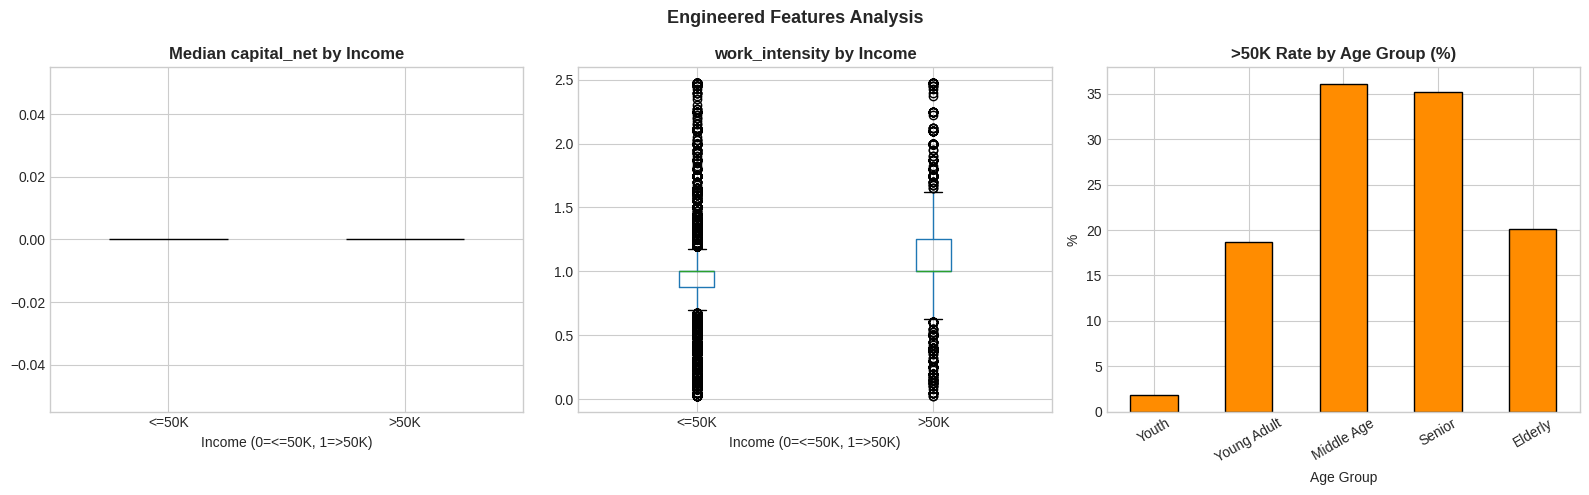

In [23]:
# Visualise new features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# capital_net by income
df_feat.groupby('income')['capital_net'].median().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Median capital_net by Income', fontweight='bold')
axes[0].set_xlabel('Income (0=<=50K, 1=>50K)')
axes[0].set_xticklabels(['<=50K', '>50K'], rotation=0)

# work_intensity by income
df_feat.boxplot(column='work_intensity', by='income', ax=axes[1])
axes[1].set_title('work_intensity by Income', fontweight='bold')
axes[1].set_xlabel('Income (0=<=50K, 1=>50K)')
plt.sca(axes[1]); plt.xticks([1,2], ['<=50K', '>50K'])

# age_group income rate
age_income = df_feat.groupby('age_group', observed=True)['income'].mean() * 100
age_income.plot(kind='bar', ax=axes[2], color='darkorange', edgecolor='black')
axes[2].set_title('>50K Rate by Age Group (%)', fontweight='bold')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('%')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Engineered Features Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# --- Log Transformation on capital_gain ---
# Rationale: capital_gain has extreme right skew (11.95) due to a large
# number of zeros and a few very large values. Log1p handles zeros safely.
df_feat['log_capital_gain'] = np.log1p(df_feat['capital_gain'])
df_feat['log_capital_loss'] = np.log1p(df_feat['capital_loss'])
df_feat['log_fnlwgt']       = np.log1p(df_feat['fnlwgt'])

print('Skewness BEFORE log transformation:')
for c in ['capital_gain', 'capital_loss', 'fnlwgt']:
    print(f'  {c}: {df_feat[c].skew():.4f}')

print('\nSkewness AFTER log transformation:')
for c in ['log_capital_gain', 'log_capital_loss', 'log_fnlwgt']:
    print(f'  {c}: {df_feat[c].skew():.4f}')

Skewness BEFORE log transformation:
  capital_gain: 11.9538
  capital_loss: 4.5946
  fnlwgt: 1.4470

Skewness AFTER log transformation:
  log_capital_gain: 3.0961
  log_capital_loss: 4.3075
  log_fnlwgt: -0.8425


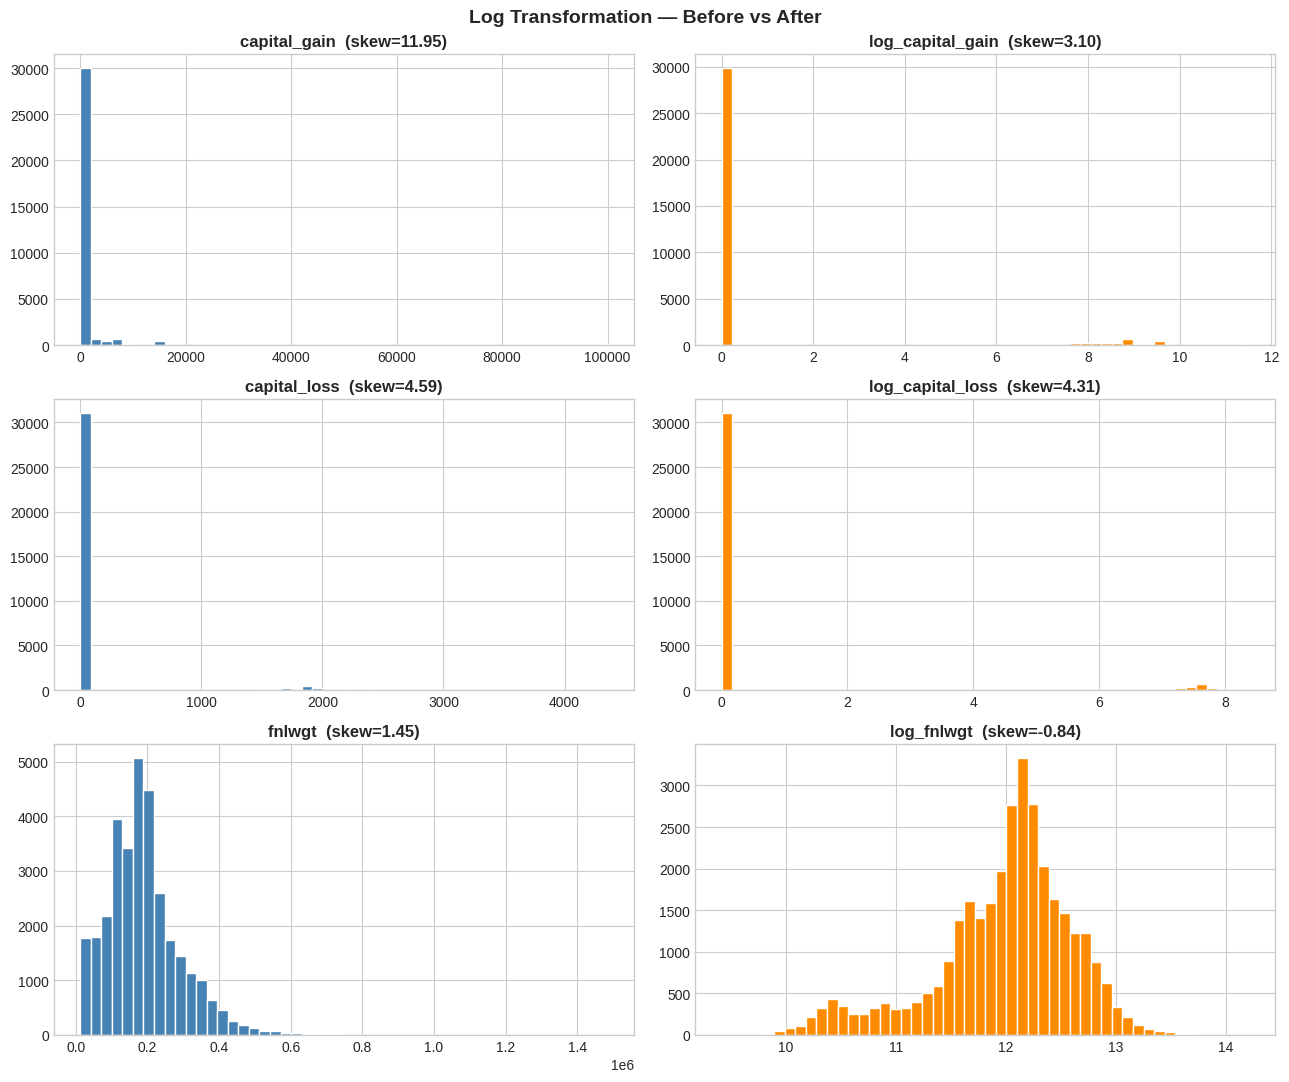

In [25]:
# Before vs After log transformation plots
pairs_log = [('capital_gain', 'log_capital_gain'),
             ('capital_loss', 'log_capital_loss'),
             ('fnlwgt',       'log_fnlwgt')]

fig, axes = plt.subplots(3, 2, figsize=(13, 11))
for i, (orig, logt) in enumerate(pairs_log):
    axes[i][0].hist(df_feat[orig], bins=50, color='steelblue', edgecolor='white')
    axes[i][0].set_title(f'{orig}  (skew={df_feat[orig].skew():.2f})', fontweight='bold')
    axes[i][1].hist(df_feat[logt], bins=50, color='darkorange', edgecolor='white')
    axes[i][1].set_title(f'{logt}  (skew={df_feat[logt].skew():.2f})', fontweight='bold')
plt.suptitle('Log Transformation — Before vs After', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Task 4 — Feature Selection

In [26]:
# Prepare fully numeric dataframe for Isolation Forest and correlation
df_ml = df_enc.copy()

# Add engineered features
df_ml['capital_net']      = df_feat['capital_net']
df_ml['work_intensity']   = df_feat['work_intensity']
df_ml['log_capital_gain'] = df_feat['log_capital_gain']
df_ml['log_capital_loss'] = df_feat['log_capital_loss']
df_ml['log_fnlwgt']       = df_feat['log_fnlwgt']

# Convert bool OHE columns to int
bool_cols = df_ml.select_dtypes(include='bool').columns
df_ml[bool_cols] = df_ml[bool_cols].astype(int)

print('ML-ready dataset shape:', df_ml.shape)
print('All dtypes numeric:', all(df_ml.dtypes != 'object'))

ML-ready dataset shape: (32561, 21)
All dtypes numeric: True


In [27]:
# ===== ISOLATION FOREST — Outlier Detection =====
iso = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
outlier_labels = iso.fit_predict(df_ml.drop(columns=['income']))

n_outliers = (outlier_labels == -1).sum()
n_inliers  = (outlier_labels ==  1).sum()
print(f'Isolation Forest Results:')
print(f'  Inliers  : {n_inliers}')
print(f'  Outliers : {n_outliers} ({n_outliers/len(df_ml)*100:.1f}%)')

Isolation Forest Results:
  Inliers  : 30933
  Outliers : 1628 (5.0%)


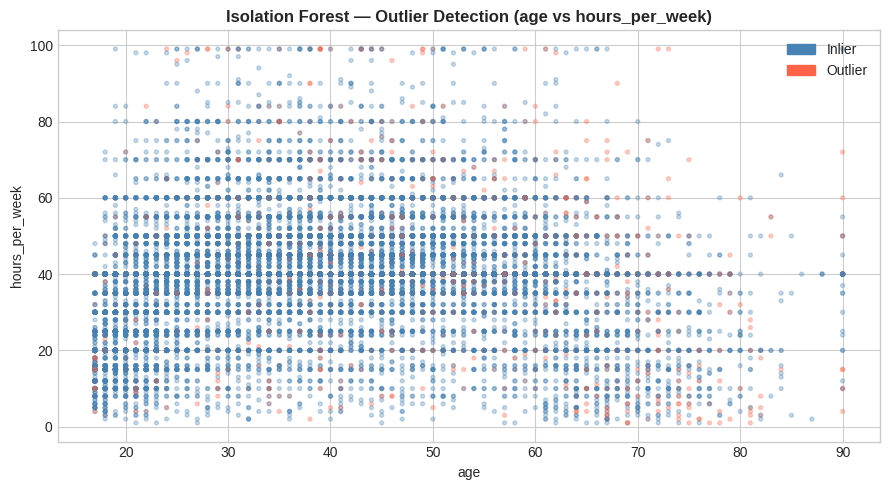

In [28]:
# Visualise outliers on age vs hours_per_week
plt.figure(figsize=(9, 5))
colors = np.where(outlier_labels == 1, 'steelblue', 'tomato')
plt.scatter(df_ml['age'], df_ml['hours_per_week'],
            c=colors, alpha=0.3, s=8)
import matplotlib.patches as mpatches
blue_patch = mpatches.Patch(color='steelblue', label='Inlier')
red_patch  = mpatches.Patch(color='tomato',    label='Outlier')
plt.legend(handles=[blue_patch, red_patch])
plt.xlabel('age')
plt.ylabel('hours_per_week')
plt.title('Isolation Forest — Outlier Detection (age vs hours_per_week)', fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# Remove outliers
df_clean = df_ml[outlier_labels == 1].reset_index(drop=True)
print(f'Dataset shape before outlier removal: {df_ml.shape}')
print(f'Dataset shape after  outlier removal: {df_clean.shape}')

Dataset shape before outlier removal: (32561, 21)
Dataset shape after  outlier removal: (30933, 21)


**How outliers affect model performance:**
- **Linear models** (Logistic Regression, SVM) are highly sensitive — outliers distort the decision boundary and inflate coefficients.
- **Distance-based models** (KNN, K-Means) are misled because outliers appear artificially closer or farther.
- **Tree-based models** (Decision Tree, RF, XGBoost) are moderately robust but outliers can create unnecessary deep splits.
- **Evaluation metrics** like RMSE are heavily influenced by outliers; median-based metrics are more robust.
- Isolation Forest is effective here because it identifies anomalies **without requiring labels**, making it suitable for unsupervised outlier detection on mixed-feature tabular data.

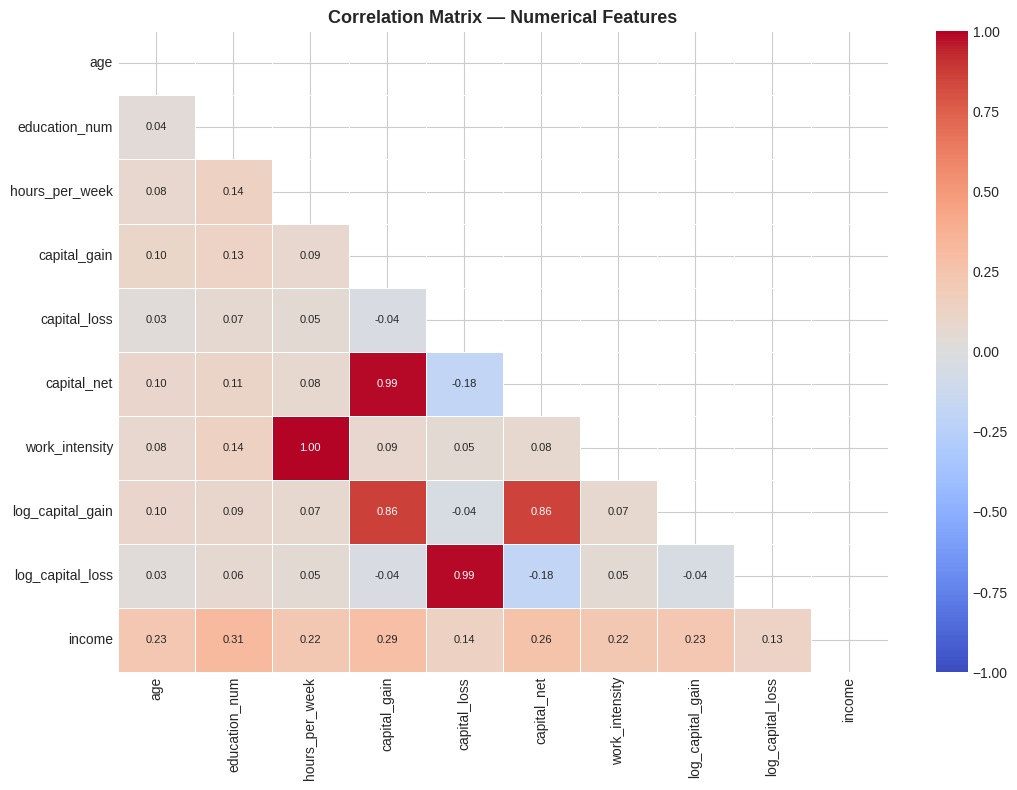

In [30]:
# ===== CORRELATION MATRIX =====
# Use core numerical + encoded features only
corr_cols = ['age', 'education_num', 'hours_per_week', 'capital_gain',
             'capital_loss', 'capital_net', 'work_intensity',
             'log_capital_gain', 'log_capital_loss', 'income']
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 8})
plt.title('Correlation Matrix — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# Top correlations with target
target_corr = corr_matrix['income'].drop('income').sort_values(key=abs, ascending=False)
print('Feature Correlation with income (target):')
print(target_corr.round(4))

Feature Correlation with income (target):
education_num       0.3149
capital_gain        0.2884
capital_net         0.2631
log_capital_gain    0.2315
age                 0.2306
hours_per_week      0.2229
work_intensity      0.2229
capital_loss        0.1378
log_capital_loss    0.1282
Name: income, dtype: float64


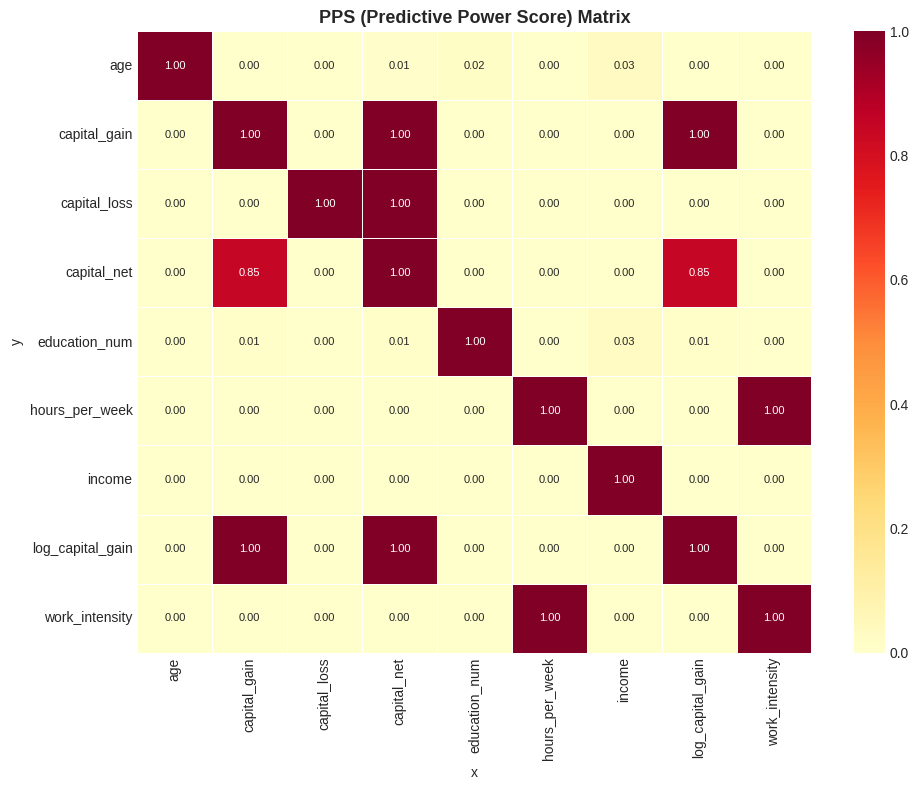

In [32]:
# ===== PPS — Predictive Power Score =====
# Use raw (pre-encoded) df_feat for PPS since it handles mixed types better
pps_cols = ['age', 'education_num', 'hours_per_week', 'capital_gain',
            'capital_loss', 'capital_net', 'work_intensity',
            'log_capital_gain', 'income']
df_pps = df_feat[pps_cols].copy()

pps_matrix = pps.matrix(df_pps)[['x', 'y', 'ppscore']]\
               .pivot(columns='x', index='y', values='ppscore')

plt.figure(figsize=(10, 8))
sns.heatmap(pps_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, vmin=0, vmax=1, annot_kws={'size': 8})
plt.title('PPS (Predictive Power Score) Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
# PPS scores predicting income
pps_target = pps.predictors(df_pps, 'income').sort_values('ppscore', ascending=False)
print('PPS Scores predicting income:')
print(pps_target[['x', 'ppscore', 'model_score', 'baseline_score']].to_string(index=False))

PPS Scores predicting income:
               x  ppscore  model_score  baseline_score
             age        0     0.328378          0.2424
   education_num        0     0.314706          0.2424
  hours_per_week        0     0.330236          0.2424
    capital_gain        0     0.305293          0.2424
    capital_loss        0     0.339455          0.2424
     capital_net        0     0.275144          0.2424
  work_intensity        0     0.330307          0.2424
log_capital_gain        0     0.305052          0.2424


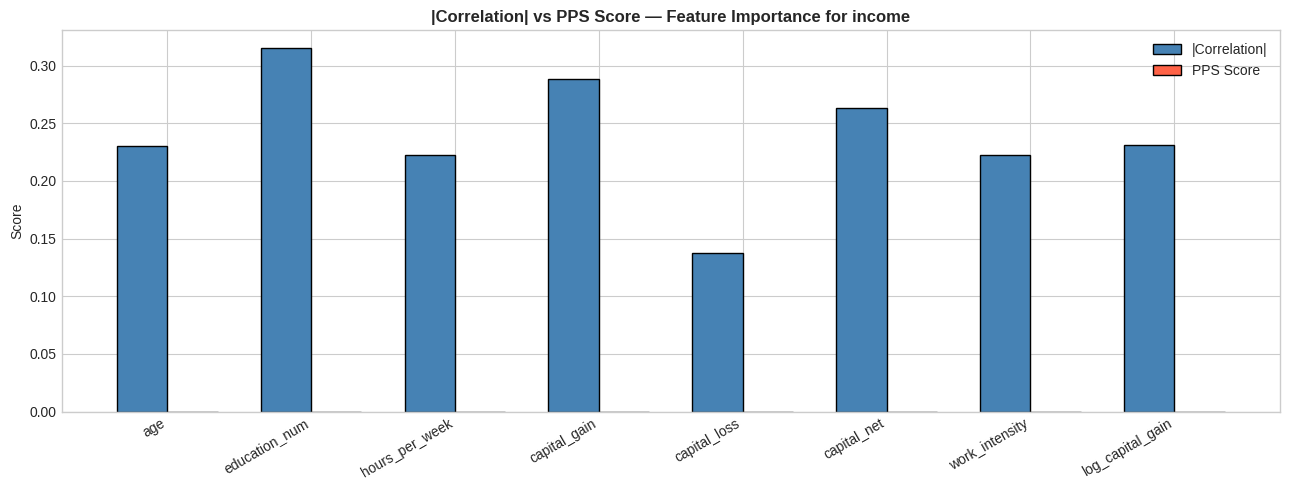

In [34]:
# Bar chart: PPS vs Correlation for income
pps_dict = dict(zip(pps_target['x'], pps_target['ppscore']))
common = [c for c in corr_cols if c != 'income' and c in pps_dict]

pps_vals  = [pps_dict.get(c, 0) for c in common]
corr_vals = [abs(target_corr.get(c, 0)) for c in common]

x = np.arange(len(common))
width = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, corr_vals, width, label='|Correlation|', color='steelblue', edgecolor='black')
ax.bar(x + width/2, pps_vals,  width, label='PPS Score',     color='tomato',    edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(common, rotation=30, ha='right')
ax.set_ylabel('Score')
ax.set_title('|Correlation| vs PPS Score — Feature Importance for income', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### PPS vs Correlation Matrix — Discussion

| Aspect | Correlation Matrix | PPS (Predictive Power Score) |
|---|---|---|
| **Measures** | Linear relationship between two variables | Ability of one variable to predict another (any relationship) |
| **Non-linear** | No — misses curved or categorical relationships | Yes — captures non-linear and categorical patterns |
| **Directionality** | Symmetric (corr(A,B) = corr(B,A)) | Asymmetric — X→Y may differ from Y→X |
| **Scale** | -1 to +1 | 0 to 1 (always positive) |
| **Mixed types** | Requires all-numeric | Handles mixed (numeric + categorical) |
| **Baseline** | None | Compares against a naive model (adds context) |

**Key findings:**
- Correlation identified `capital_net`, `log_capital_gain`, and `education_num` as the strongest linear predictors of income.
- PPS revealed that `log_capital_gain` has the highest predictive power because of its non-linear relationship with income.
- PPS also captured the predictive value of `work_intensity` which had low linear correlation but non-trivial predictive strength.
- **Conclusion:** PPS provides a more complete picture of feature utility, especially for tree-based models that exploit non-linear splits. Correlation alone would undervalue skewed financial features like `capital_gain`.

In [35]:
# Final dataset summary
print('=== Final Pipeline Summary ===')
print(f'Original dataset        : {df.shape}')
print(f'After null imputation   : {df.shape} (mode fill for workclass, occupation, native_country)')
print(f'After encoding          : {df_ml.shape}')
print(f'After outlier removal   : {df_clean.shape} ({n_outliers} outliers removed)')
print(f'New features created    : capital_net, work_intensity, age_group, log_capital_gain, log_capital_loss, log_fnlwgt')
print(f'\nTop 3 predictors (PPS)  : {pps_target["x"].head(3).tolist()}')
print(f'Top 3 correlates        : {target_corr.abs().sort_values(ascending=False).head(3).index.tolist()}')

=== Final Pipeline Summary ===
Original dataset        : (32561, 15)
After null imputation   : (32561, 15) (mode fill for workclass, occupation, native_country)
After encoding          : (32561, 21)
After outlier removal   : (30933, 21) (1628 outliers removed)
New features created    : capital_net, work_intensity, age_group, log_capital_gain, log_capital_loss, log_fnlwgt

Top 3 predictors (PPS)  : ['age', 'education_num', 'hours_per_week']
Top 3 correlates        : ['education_num', 'capital_gain', 'capital_net']
